# 04. Comparação Final: erro de previsão por horizonte (h = 1, 2, 3)

Este notebook consolida os resultados do `02_baseline_modelos_classicos` e do `03_machine_learning` para responder à pergunta central do case:

> Como o erro de previsão do `Close` se comporta para 1, 2 e 3 dias úteis à frente, e qual modelo é o melhor em cada horizonte?

Todas as previsões vêm do mesmo esquema de validação walk-forward (17 origens, respeitando o tempo), então as comparações abaixo são diretas.

In [1]:
import sys
sys.path.append("../src")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import case_utils as cu

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#444444", "axes.grid": True,
    "grid.color": "#e5e5e5", "grid.linewidth": 0.8, "font.size": 11,
})


In [2]:
results_classicos = pd.read_csv("../results/predictions_classicos.csv")
results_ml = pd.read_csv("../results/predictions_ml.csv")
results_all = pd.concat([results_classicos, results_ml], ignore_index=True)

metrics_all = cu.summarize_by_horizon(results_all)
metrics_all.to_csv("../results/metrics_finais.csv", index=False)
print(f"{results_all['model'].nunique()} modelos x {len(cu.HORIZONS)} horizontes x 17 origens = {len(results_all)} previsões avaliadas")


8 modelos x 3 horizontes x 17 origens = 408 previsões avaliadas


## Tabela: MAPE (%) por modelo e horizonte

In [3]:
tabela_mape = metrics_all.pivot(index="model", columns="horizon", values="MAPE").round(2)
tabela_mape.columns = [f"h={h}" for h in tabela_mape.columns]
tabela_mape["média (h1-h3)"] = tabela_mape.mean(axis=1).round(2)
tabela_mape.sort_values("média (h1-h3)")


,h=1,h=2,h=3,média (h1-h3)
model,,,,
holt,5.11,5.12,4.41,4.88
arima,5.23,5.49,4.94,5.22
sarima,5.23,5.49,4.94,5.22
ses,5.24,5.38,5.18,5.27
naive,5.25,5.42,5.22,5.30
holt_winters,5.33,5.57,5.02,5.31
ml_ridge,6.43,5.60,7.71,6.58
seasonal_naive,13.55,10.72,9.13,11.13


## Tabela: RMSE (US$) por modelo e horizonte

In [4]:
tabela_rmse = metrics_all.pivot(index="model", columns="horizon", values="RMSE").round(3)
tabela_rmse.columns = [f"h={h}" for h in tabela_rmse.columns]
tabela_rmse["média (h1-h3)"] = tabela_rmse.mean(axis=1).round(3)
tabela_rmse.sort_values("média (h1-h3)")


,h=1,h=2,h=3,média (h1-h3)
model,,,,
holt,1.266,1.176,0.928,1.123
ses,1.266,1.179,1.048,1.164
naive,1.269,1.187,1.053,1.170
arima,1.287,1.233,1.024,1.181
sarima,1.287,1.233,1.024,1.181
holt_winters,1.288,1.226,1.029,1.181
ml_ridge,1.425,1.057,1.479,1.320
seasonal_naive,3.107,2.399,2.009,2.505


## Ganho relativo ao baseline Naïve, por horizonte

In [5]:
naive_rmse = metrics_all[metrics_all["model"] == "naive"].set_index("horizon")["RMSE"]

ganho = metrics_all.copy()
ganho["rmse_naive"] = ganho["horizon"].map(naive_rmse)
ganho["ganho_vs_naive_%"] = (1 - ganho["RMSE"] / ganho["rmse_naive"]) * 100

tabela_ganho = ganho.pivot(index="model", columns="horizon", values="ganho_vs_naive_%").round(1)
tabela_ganho.columns = [f"h={h}" for h in tabela_ganho.columns]
tabela_ganho.loc[[m for m in tabela_ganho.index if m != "naive"]].sort_values("h=1", ascending=False)


,h=1,h=2,h=3
model,,,
holt,0.2,1.0,11.9
ses,0.2,0.7,0.5
arima,-1.5,-3.9,2.8
holt_winters,-1.5,-3.3,2.3
sarima,-1.5,-3.9,2.8
ml_ridge,-12.3,11.0,-40.4
seasonal_naive,-144.9,-102.1,-90.7


Valores positivos significam que o modelo reduz o RMSE em relação ao Naïve naquele horizonte. Valores negativos significam que o modelo é pior que simplesmente repetir o último preço conhecido.

## Erro por horizonte, todos os modelos

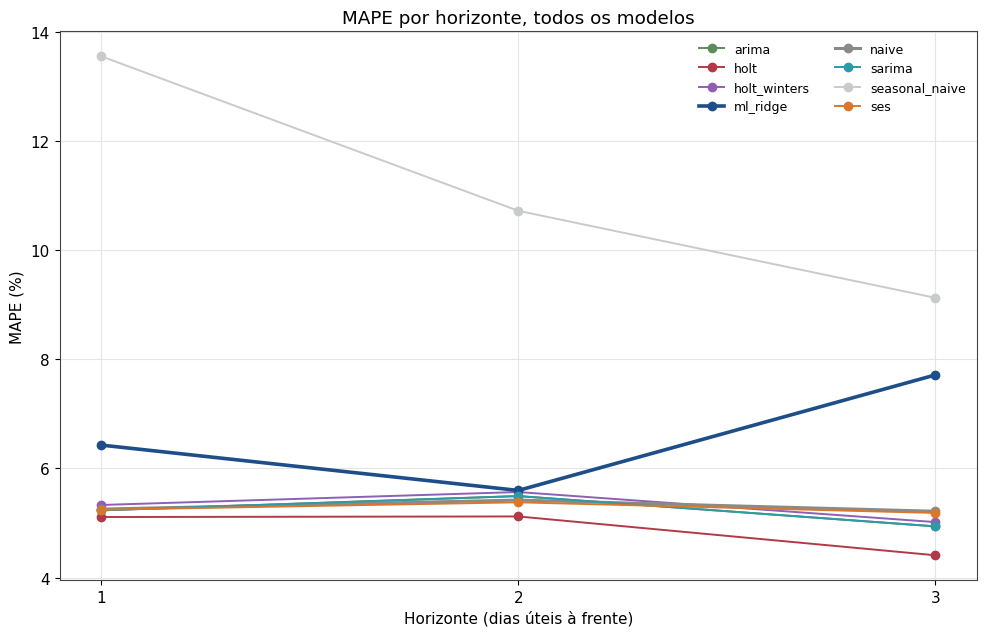

In [6]:
fig, ax = plt.subplots(figsize=(10, 6.5))
for model, g in metrics_all.groupby("model"):
    g = g.sort_values("horizon")
    lw = 2.6 if model.startswith("ml_") else (2.2 if model == "naive" else 1.4)
    ax.plot(g["horizon"], g["MAPE"], marker="o", markersize=6, linewidth=lw,
            color=cu.PALETTE.get(model, "#999999"), label=model)
ax.set_xticks(cu.HORIZONS)
ax.set_xlabel("Horizonte (dias úteis à frente)")
ax.set_ylabel("MAPE (%)")
ax.set_title("MAPE por horizonte, todos os modelos")
ax.legend(frameon=False, ncol=2, fontsize=9)
fig.tight_layout()
plt.show()


## Ranking médio (h=1 a h=3) por RMSE

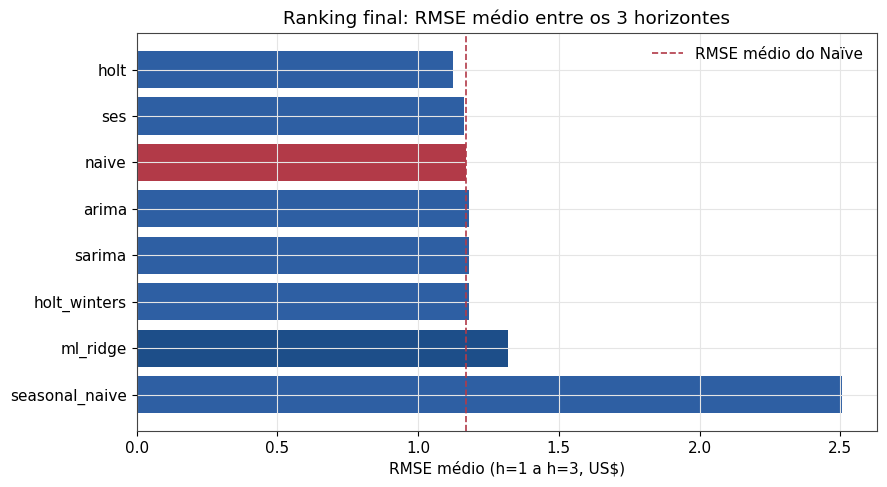

In [7]:
ranking = tabela_rmse["média (h1-h3)"].sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#B23A48" if m == "naive" else (cu.PALETTE.get(m, "#D9782D") if m.startswith("ml_") else "#2E5FA3") for m in ranking.index]
ax.barh(ranking.index, ranking.values, color=colors)
ax.axvline(ranking["naive"], color="#B23A48", linestyle="--", linewidth=1.2, label="RMSE médio do Naïve")
ax.invert_yaxis()
ax.set_xlabel("RMSE médio (h=1 a h=3, US$)")
ax.set_title("Ranking final: RMSE médio entre os 3 horizontes")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## Exemplo visual: previsões de 1, 2 e 3 dias em algumas origens

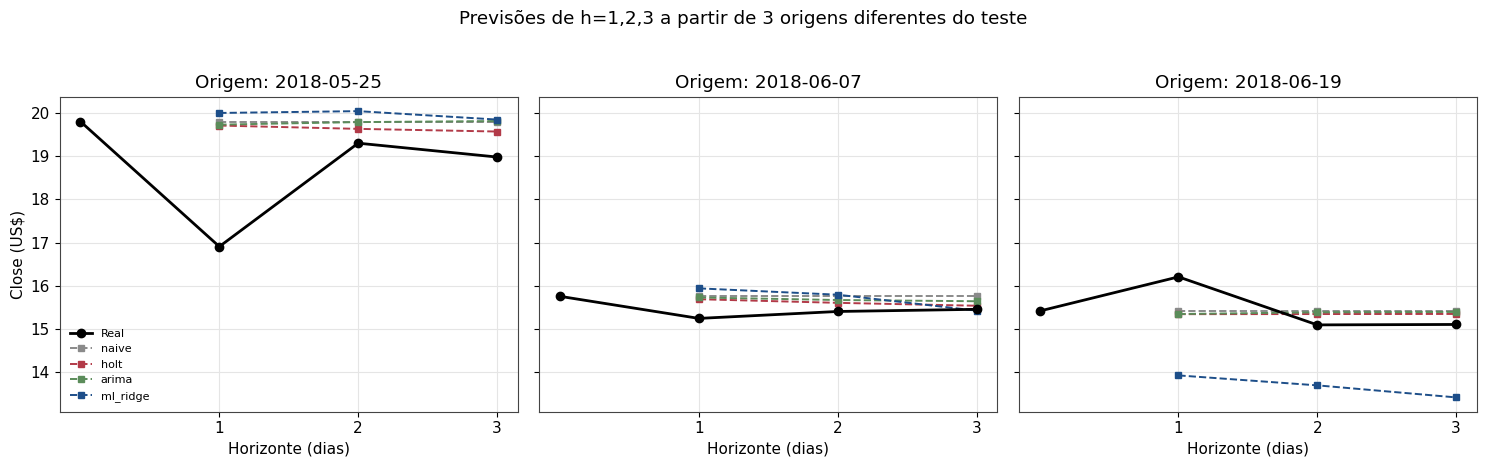

In [8]:
sample_origins = results_all["origin_date"].drop_duplicates().sort_values().iloc[[0, 8, 16]]
modelos_plot = ["naive", "holt", "arima"] + [m for m in results_all["model"].unique() if m.startswith("ml_")]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, origin_date in zip(axes, sample_origins):
    real = results_all[(results_all["origin_date"] == origin_date) & (results_all["model"] == "naive")].sort_values("horizon")
    valor_na_origem = real["y_pred"].iloc[0]
    ax.plot([0] + list(real["horizon"]), [valor_na_origem] + list(real["y_true"]),
            color="black", marker="o", linewidth=2, label="Real", zorder=5)
    for m in modelos_plot:
        g = results_all[(results_all["origin_date"] == origin_date) & (results_all["model"] == m)].sort_values("horizon")
        ax.plot(g["horizon"], g["y_pred"], marker="s", markersize=5, linestyle="--", linewidth=1.4,
                color=cu.PALETTE.get(m, "#999999"), label=m)
    ax.set_title(f"Origem: {pd.to_datetime(origin_date).date()}")
    ax.set_xlabel("Horizonte (dias)")
    ax.set_xticks(cu.HORIZONS)
axes[0].set_ylabel("Close (US$)")
axes[0].legend(frameon=False, fontsize=8, loc="best")
fig.suptitle("Previsões de h=1,2,3 a partir de 3 origens diferentes do teste", y=1.03)
fig.tight_layout()
plt.show()


## Conclusão

Achado principal: o erro por horizonte não cresce de forma de livro-texto. MAPE e RMSE ficam parecidos entre h=1, h=2 e h=3 para quase todos os modelos, ao invés de aumentar monotonicamente. Isso é resultado direto da série se comportar como um passeio aleatório com tendência de curto prazo: o que domina o erro não é quantos dias à frente estão sendo previstos, e sim a magnitude do próximo movimento de preço, que é parecida em qualquer horizonte curto.

Achado 2: desta vez o Machine Learning não superou os modelos clássicos. Diferente de uma rodada anterior de testes, na qual o Ridge batia o Naïve por larga margem prevendo 19 dias à frente de uma só vez, aqui, com validação walk-forward e horizontes curtos de 1 a 3 dias, os modelos clássicos simples (Holt e o próprio Naïve/ARIMA) empatam ou superam o Ridge. Duas explicações são prováveis:

- A validação interna do notebook 03 (últimos 40 dias do treino) ficou toda antes do choque de -13,7% que antecede o teste, então o Ridge aprendeu um regime de mercado que não é exatamente o mesmo do período avaliado.
- Em horizontes muito curtos (1 a 3 dias), o sinal que o Ridge extrai de médias móveis e lags é pequeno demais para compensar o ruído. O último preço observado (Naïve) já é uma previsão difícil de melhorar de forma consistente.

Recomendação prática: para previsão de curtíssimo prazo (1 a 3 dias) neste ativo, o ganho de complexidade do Machine Learning não se pagou nesta janela de teste. Um modelo simples, como o Holt com tendência amortecida, entrega desempenho igual ou melhor com muito menos manutenção. Isso não invalida a abordagem de ML, apenas sugere que, para gerar valor real, seriam necessários mais dados de treino cobrindo o mesmo regime de mercado do teste e variáveis exógenas (notícias, indicadores de mercado, dados macro) que expliquem os choques que uma série univariada de preço não consegue antecipar.